In [3]:
#importando bibliotecas
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from matplotlib import pyplot as plt
%matplotlib inline

import requests
from io import BytesIO

In [4]:
#carrega a base de bados
df = pd.read_csv('vinhos_dataset_sem_outliers.csv' , index_col=0)

In [5]:
# Certificando que esta usando a df sem duplicadas
df.shape

(5266, 10)

In [6]:
#mostra cabecario e primeiras 5 linhas
df.head()

,residual_sugar,chlorides,density,pH,sulphates,alcohol,quality,color,combined_acidity,combined_sulfur_dioxide
citric_acid,,,,,,,,,,
0.00,1.9,0.076,0.9978,3.51,0.56,9.4,5,0,0.194643,-82.339801
0.00,2.6,0.098,0.9968,3.20,0.68,9.8,5,0,0.599492,-47.003146
0.04,2.3,0.092,0.9970,3.26,0.65,9.8,5,0,0.596156,-61.956149
0.56,1.9,0.075,0.9980,3.16,0.58,9.8,6,0,3.981499,-55.656877
0.00,1.8,0.075,0.9978,3.51,0.56,9.4,5,0,0.193531,-76.040530


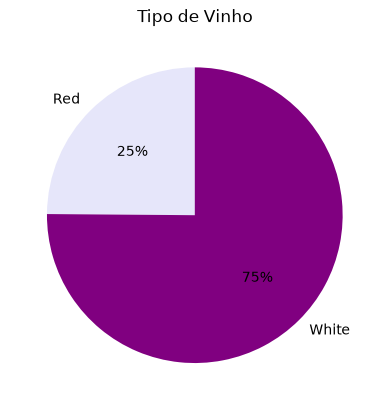

In [7]:
# PLotando em formato pizza a quantidade em % de vinhos red e white
num_red = df[df['color'] == 0].shape[0]

num_white = df[df['color'] == 1].shape[0]

plt.pie(
    [num_red, num_white],
    labels=['Red', 'White'],
    startangle=90,
    autopct='%1.f%%',
    colors=['lavender', 'purple']
)

plt.title('Tipo de Vinho')

plt.show()

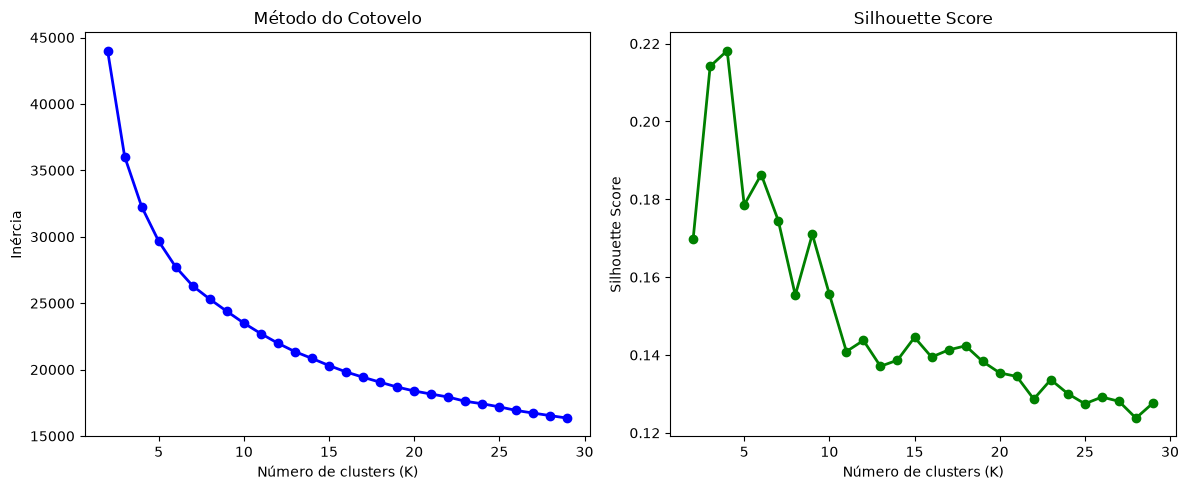

In [8]:
#importando bibliotecas faltantes
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Carrega a df novamente (nao entendi porque teve que carregar novamente ?)
df = pd.read_csv(
    "vinhos_dataset_reduced.csv"
)

# Seleciona todos os "features" exceto qualidade e cor
features = [
    'citric_acid', 'residual_sugar', 'chlorides', 'density', 'pH',
       'sulphates', 'alcohol', 'combined_acidity',
       'combined_sulfur_dioxide' , 'quality'
]

X = df[features]

# Faz o scaler dos "features" usando o standardscaler e transforma usando a formula z = X - X_mean / X_std - agora todos os valores estao em escalas parecidas e nao pH entre 1 e 14 e sultatios entre 0 e 1 por examplo
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Teste do numero de clusters (nao funcionou com 1 a 30)
ks = range(2, 30)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

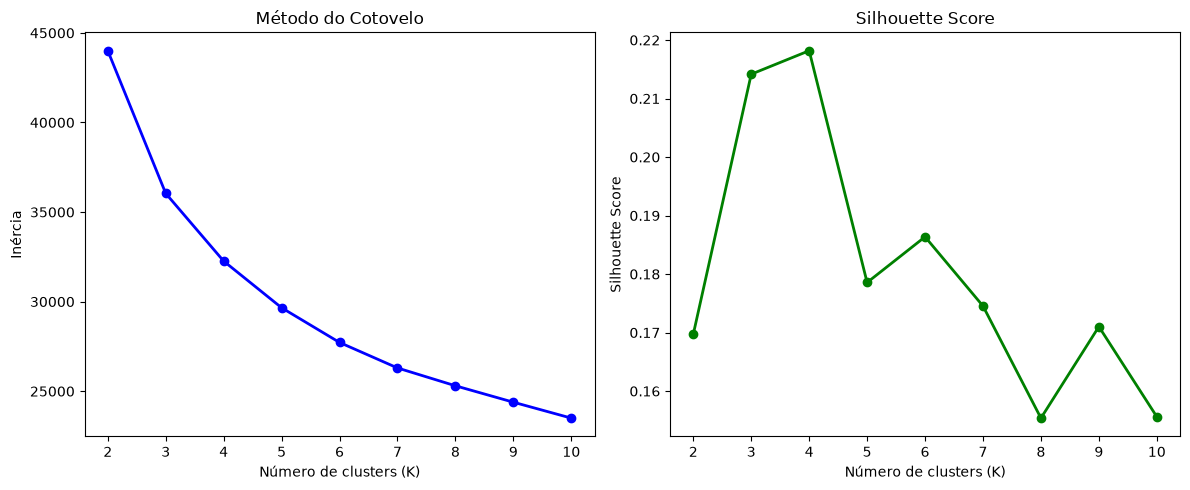

In [9]:
# Teste do numero de clusters (agora somente 10 ks - 2 a 11 por curiosidade)
ks = range(2, 11)

inercias = []
silhouettes = []

for k in ks:

    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        max_iter=300,
        tol=1e-4,
        random_state=42
    )

    labels = km.fit_predict(X_scaled)

    # Inercia
    inercias.append(km.inertia_)

    # Silhouette
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

# Plota os diagnosticos
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Elbow
ax1.plot(ks, inercias, 'bo-', linewidth=2)
ax1.set_title('Método do Cotovelo')
ax1.set_xlabel('Número de clusters (K)')
ax1.set_ylabel('Inércia')

# Silhouette
ax2.plot(ks, silhouettes, 'go-', linewidth=2)
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Número de clusters (K)')
ax2.set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()

In [10]:
# K-Means com 3 clusters (do grafico de Silhoetes (distancia entre pontos mesmo cluster e distancia de outros clusters) no ponto de inflexao ja que o ponto de inflexao de inercia (distancia entre pontos do mesmo cluster) nao e muito nitido)
kmeans = KMeans(
    n_clusters=3,
    init='k-means++',
    n_init=10,
    max_iter=300,
    random_state=42
)

# Ajusta o modelo e atribui cada vinho a um cluster
df['cluster'] = kmeans.fit_predict(X_scaled)

# contagem de vinhos red e whites de cada cluster
cluster_color = pd.crosstab(
    df['cluster'],
    df['color']
)

print(cluster_color)

# contagem de vinhos qualidades de cada cluster
cluster_quality = pd.crosstab(
    df['cluster'],
    df['quality']
)

print(cluster_quality)

color       0     1
cluster            
0        1248    79
1          11  1691
2         100  2191
quality   3   4    5     6    7    8  9
cluster                                
0        12  64  589   512  140   10  0
1        14  87  814   703   76    7  1
2         4  55  349  1108  640  131  4


In [11]:
# Resumo de cada cluster

summary = df.groupby('cluster')[features + ['quality']].agg(
    ['mean', 'std', 'min', 'max']
)

summary

citric_acid                      residual_sugar                       \
               mean       std  min   max           mean       std  min   max   
cluster                                                                        
0          0.287430  0.194459  0.0  1.00       2.493482  1.249545  0.8  15.5   
1          0.351152  0.139608  0.0  1.00       9.597033  4.802808  0.8  65.8   
2          0.312226  0.111958  0.0  1.66       3.149236  2.496394  0.6  15.5   

        chlorides            ... combined_sulfur_dioxide              \
             mean       std  ...                     min         max   
cluster                      ...                                       
0        0.090251  0.051637  ...             -111.429443   94.856174   
1        0.053223  0.026168  ...              -76.678932  376.755674   
2        0.039826  0.012554  ...             -110.456304  179.885032   

          quality                                                
             mean       std min max      mean       std min max  
cluster                                                          
0        5.553127  0.809076   3   8  5.553127  0.809076   3   8  
1        5.449471  0.721369   3   9  5.449471  0.721369   3   9  
2        6.193365  0.866489   3   9  6.193365  0.866489   3   9  

[3 rows x 44 columns]

In [ ]:
# Calcula as estatísticas agrupadas por cluster
resumo = df.groupby('cluster')[features].agg(['mean', 'std', 'min', 'max'])

# Transpõe a tabela (Gira os clusters para as colunas e variáveis para as linhas)
resumo_transposto = resumo.T

# Organiza o índice duplo para virar duas colunas normais ("Variável" e "Métrica")
resumo_transposto = resumo_transposto.reset_index()
resumo_transposto.rename(columns={'level_0': 'Variável', 'level_1': 'Métrica'}, inplace=True)

# Envia o resultado final para a área de transferência
resumo_transposto.to_clipboard(excel=True, index=True)



Variância explicada - PC1: 26.09%, PC2: 21.74% (Total: 47.82%)


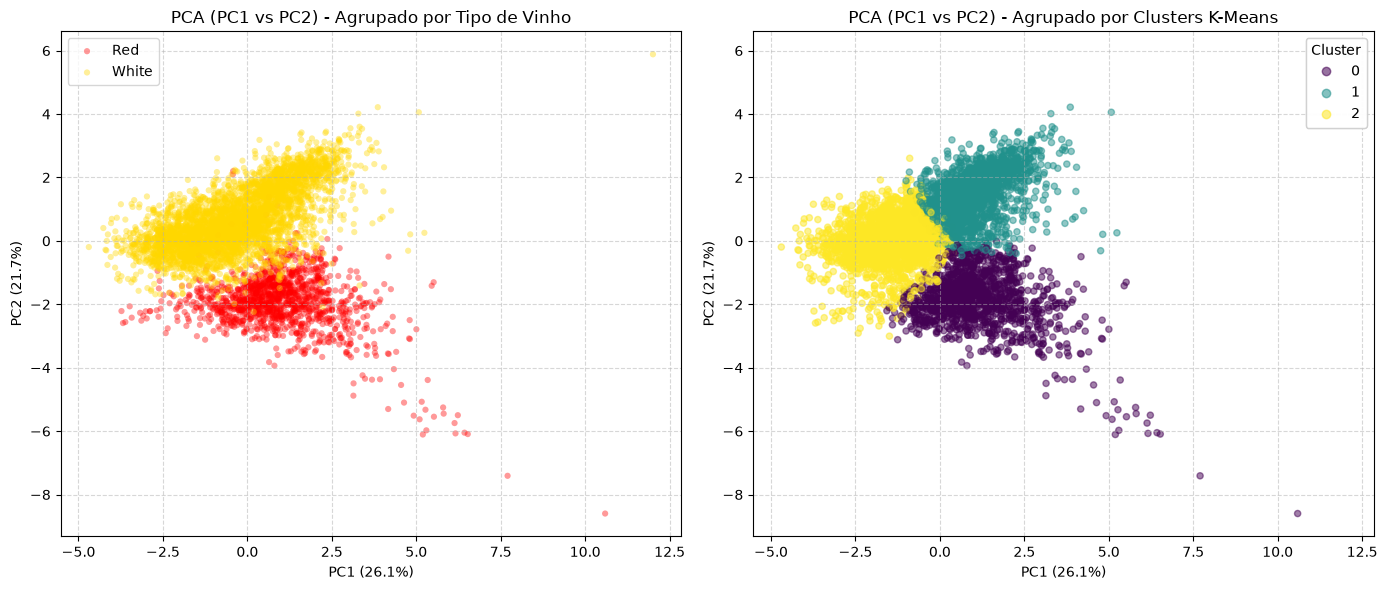

In [13]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ---------------------------------------------------------
# Seleção das colunas utilizadas no PCA
# ---------------------------------------------------------

features = [
    'citric_acid',
    'residual_sugar',
    'chlorides',
    'density',
    'pH',
    'sulphates',
    'alcohol',
    'combined_acidity',
    'combined_sulfur_dioxide',
    'quality'
]

X = df[features]


# ---------------------------------------------------------
# Normalização dos dados
# ---------------------------------------------------------
# O StandardScaler coloca todas as variáveis na mesma escala.
# Mesmo que os dados já tenham sido normalizados anteriormente,
# aplicar novamente não causa problema para o PCA.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# ---------------------------------------------------------
# Aplicação do PCA
# ---------------------------------------------------------

pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)


# ---------------------------------------------------------
# Criar DataFrame com PC1 e PC2
# ---------------------------------------------------------

df_pca = pd.DataFrame(
    principal_components,
    columns=['PC1', 'PC2'],
    index=df.index
)

# Adicionar o tipo de vinho
df_pca['color'] = df['color']


# Adicionar os clusters, caso eles já tenham sido calculados
if 'cluster' in df.columns:
    df_pca['cluster'] = df['cluster']


# ---------------------------------------------------------
# Variância explicada pelo PCA
# ---------------------------------------------------------

exp_var = pca.explained_variance_ratio_

print(
    f'Variância explicada - '
    f'PC1: {exp_var[0] * 100:.2f}%, '
    f'PC2: {exp_var[1] * 100:.2f}% '
    f'(Total: {exp_var.sum() * 100:.2f}%)'
)


# ---------------------------------------------------------
# Criar os gráficos
# ---------------------------------------------------------

fig, (ax1, ax2) = plt.subplots(
    1,
    2,
    figsize=(14, 6)
)


# ---------------------------------------------------------
# Gráfico 1 - Tipo de vinho
# ---------------------------------------------------------

colors_map = {
    0: 'red',
    1: 'gold'
}

labels_map = {
    0: 'Red',
    1: 'White'
}

for wine_type, group in df_pca.groupby('color'):

    ax1.scatter(
        group['PC1'],
        group['PC2'],
        c=colors_map[wine_type],
        label=labels_map[wine_type],
        alpha=0.4,
        edgecolors='none',
        s=20
    )


ax1.set_title(
    'PCA (PC1 vs PC2) - Agrupado por Tipo de Vinho'
)

ax1.set_xlabel(
    f'PC1 ({exp_var[0] * 100:.1f}%)'
)

ax1.set_ylabel(
    f'PC2 ({exp_var[1] * 100:.1f}%)'
)

ax1.legend()
ax1.grid(
    True,
    linestyle='--',
    alpha=0.5
)


# ---------------------------------------------------------
# Gráfico 2 - Clusters do K-Means
# ---------------------------------------------------------

if 'cluster' in df_pca.columns:

    scatter = ax2.scatter(
        df_pca['PC1'],
        df_pca['PC2'],
        c=df_pca['cluster'],
        cmap='viridis',
        alpha=0.5,
        s=20
    )

    legend2 = ax2.legend(
        *scatter.legend_elements(),
        title='Cluster',
        loc='upper right'
    )

    ax2.add_artist(legend2)

    ax2.set_title(
        'PCA (PC1 vs PC2) - Agrupado por Clusters K-Means'
    )

    ax2.set_xlabel(
        f'PC1 ({exp_var[0] * 100:.1f}%)'
    )

    ax2.set_ylabel(
        f'PC2 ({exp_var[1] * 100:.1f}%)'
    )

    ax2.grid(
        True,
        linestyle='--',
        alpha=0.5
    )

else:

    ax2.set_title(
        'Clusters K-Means não encontrados'
    )

    ax2.axis('off')


# ---------------------------------------------------------
# 7. Mostrar os gráficos
# ---------------------------------------------------------

plt.tight_layout()
plt.show()


In [14]:
# Obtém os pesos (loadings) das variáveis em PCA1 e PCA2

loadings = pd.DataFrame(
    pca.components_.T,
    columns=['PCA1', 'PCA2'],
    index=features
)

print(loadings)

                             PCA1      PCA2
citric_acid              0.159959  0.104461
residual_sugar           0.254197  0.469470
chlorides                0.335950 -0.336219
density                  0.558685  0.008848
pH                      -0.130636 -0.247937
sulphates                0.203039 -0.416332
alcohol                 -0.463758 -0.179320
combined_acidity         0.341147 -0.280422
combined_sulfur_dioxide  0.035727  0.554033
quality                 -0.306245 -0.054906


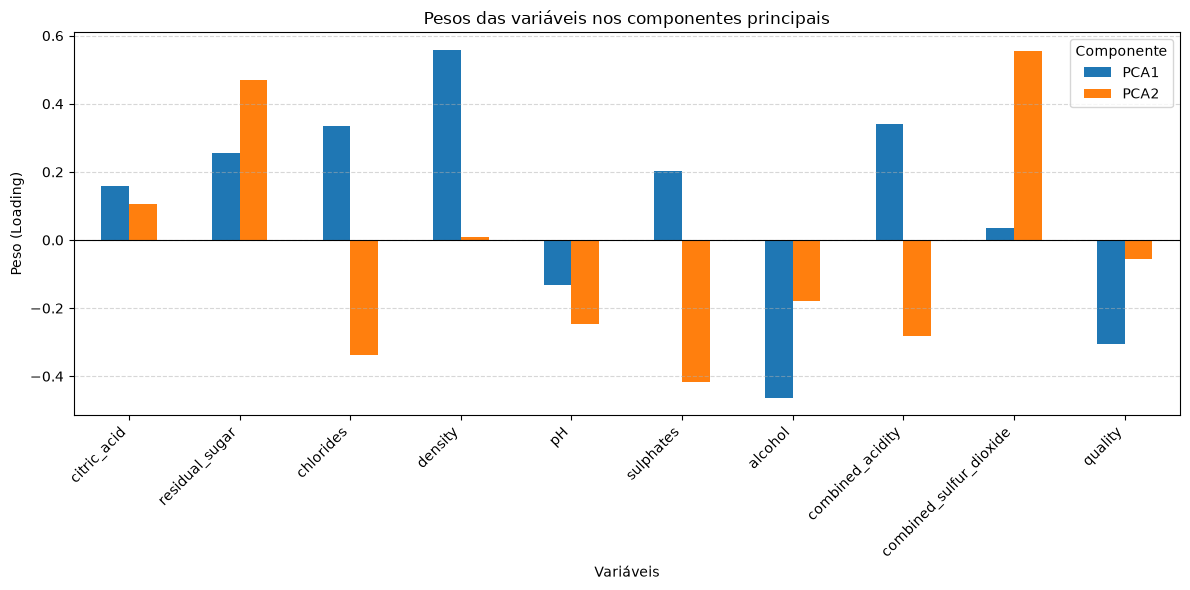

In [15]:
# Gráfico dos pesos das variáveis em PCA1 e PCA2

loadings.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Pesos das variáveis nos componentes principais')
plt.xlabel('Variáveis')
plt.ylabel('Peso (Loading)')
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Componente')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

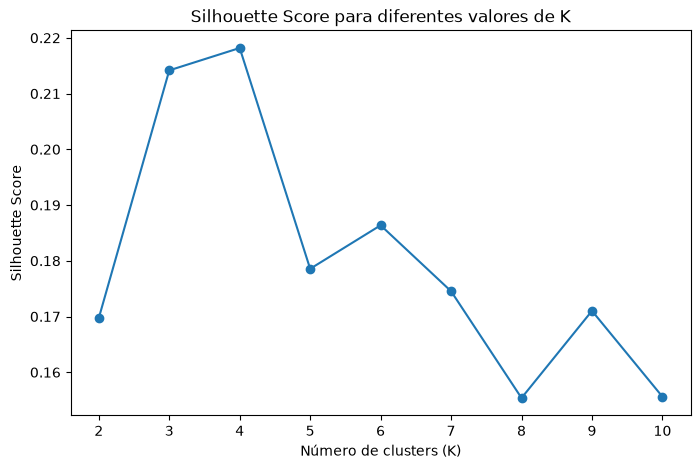

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), silhouette_scores, marker='o')

plt.xlabel('Número de clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score para diferentes valores de K')

plt.show()

Silhouette Score médio: 0.21817638252894256


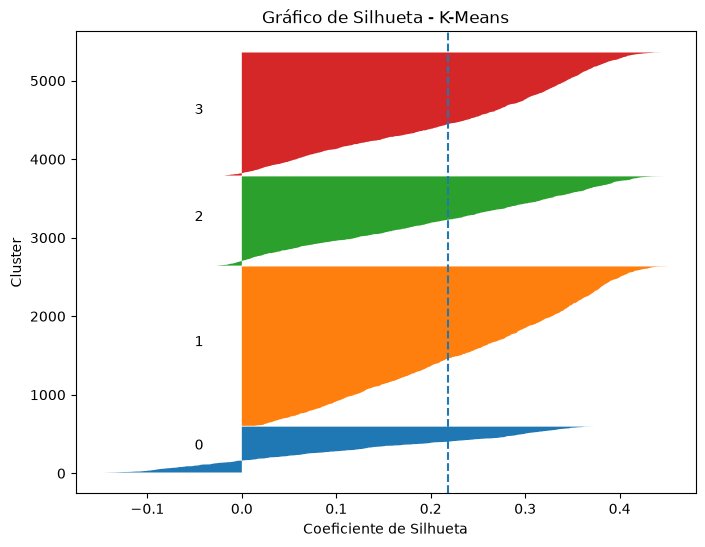

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# Criar o modelo K-Means
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fazer o agrupamento
labels = kmeans.fit_predict(X_scaled)

# Calcular o Silhouette Score médio
silhouette_avg = silhouette_score(X_scaled, labels)

print("Silhouette Score médio:", silhouette_avg)

# Calcular o valor de silhueta de cada observação
sample_silhouette_values = silhouette_samples(X_scaled, labels)

# Criar o gráfico
fig, ax = plt.subplots(figsize=(8, 6))

y_lower = 10

for cluster in range(4):

    # Valores de silhueta do cluster atual
    cluster_values = sample_silhouette_values[labels == cluster]

    # Ordenar os valores
    cluster_values.sort()

    # Tamanho do cluster
    cluster_size = len(cluster_values)

    y_upper = y_lower + cluster_size

    ax.fill_betweenx(
        np.arange(y_lower, y_upper),
        0,
        cluster_values
    )

    ax.text(
        -0.05,
        y_lower + 0.5 * cluster_size,
        str(cluster)
    )

    y_lower = y_upper + 10

# Linha mostrando a média
ax.axvline(
    silhouette_avg,
    linestyle="--"
)

ax.set_title("Gráfico de Silhueta - K-Means")
ax.set_xlabel("Coeficiente de Silhueta")
ax.set_ylabel("Cluster")

plt.show()